#### OpenCV API
- 사이트: https://opencv.org/releases/

In [ ]:
#pip install opencv-python

1. 정지영상 출력

- 영상 파일 읽어와 출력하기

In [7]:
import cv2
import sys

# 이미지(영상) 읽어오기
img = cv2.imread('./data/road1.jpg')

# 파일이 없는 경우 종료
if img is None:
    sys.exit('선택한 파일이 없습니다.')

# 화면출력(윈도우)
cv2.imshow('TestImg', img)

# 종료명령
cv2.waitKey(0)
cv2.destroyAllWindows()

In [2]:
print(type(img))

<class 'numpy.ndarray'>


In [6]:
print(img.shape)

(720, 1080, 3)


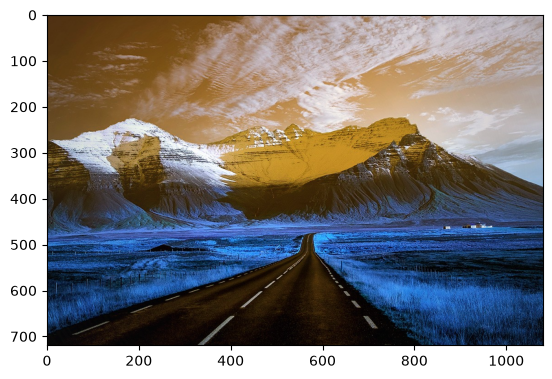

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

- cv2.imread('./data/road1.jpg') => BGR 형식으로 읽어옴
    - matplotlib 이미지 출력 => RGB 형식으로 출력
    - 따라서 cv2로 읽어온 이미지를 matplotlib으로 출력시 RGB로 변경 필요

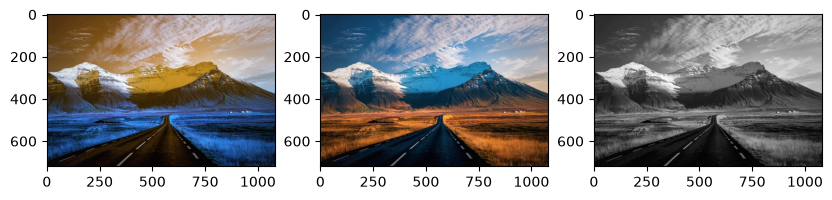

In [8]:
imgBGR = cv2.imread('./data/road1.jpg')
imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)
imgGray = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
# CV2 출력
plt.subplot(131)
plt.imshow(imgBGR)
# RGB 출력
plt.subplot(132)
plt.imshow(imgRGB)
# 크레이스타일 출력
plt.subplot(133)
plt.imshow(imgGray, cmap='gray')

plt.show()

2. 동영상 출력(웹 캠)
- 일반 출력

In [3]:
import cv2
import sys

# 웹캠 연결
cap = cv2.VideoCapture(0)

# 웹캠 정보 화면 출력
while True:
    ret, frame = cap.read()  # 화면 프레임 읽어오기

    if not ret:
        print('카메라 연결 오류')
        break

    cv2.imshow('Webcam', frame)  # 화면에 프레임 출력

    # q 키 입력시 종료
    if cv2.waitKey(1) & 0xFF == 27:    # ord('q'): 특정 값 입력, 27 => ESC 키
        break

# 모든 자원 해제
cap.release()  # 카메라 종료
cv2.destroyAllWindows() # 출력중인 모든창 닫기

카메라 연결 오류


[ WARN:0@13.076] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@13.076] global cap.cpp:435 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(5.0.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1243: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@13.076] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


- s 키를 누르면 현재 프레임 저장

In [2]:
import cv2
import sys

# 웹캠 연결
cap = cv2.VideoCapture(0)

count = 1

# 웹캠 정보 화면 출력
while True:
    ret, frame = cap.read()  # 화면 프레임 읽어오기

    if not ret:
        print('카메라 연결 오류')
        break

    cv2.imshow('Webcam', frame)  # 화면에 프레임 출력

    # 사용자 입력키 받아오기
    key = cv2.waitKey(1) & 0xFF

    # s 키를 누르면 이미지 저장
    if key == ord('s'):
        filename = f'./images/capture_{count}.jpg'
        cv2.imwrite(filename, frame)  # 현재 프래임 저장
        print(f'{filename} 저장 완료')
        count += 1
    # ESC 입력시 종료
    elif key == 27:
        break 

# 모든 자원 해제
cap.release()  # 카메라 종료
cv2.destroyAllWindows() # 출력중인 모든창 닫기

카메라 연결 오류


[ WARN:0@2.213] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@2.213] global cap.cpp:435 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(5.0.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1243: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@2.213] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


- 추출한 이미지 3개 화면출력하기

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

fnames = os.listdir('./imgs')

imgList = []

if len(fnames) > 0:
    for i in range(1, 4):
        img = cv2.imread(f'./imgs/capture_{i}.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgList.append(img)

    imgs = np.hstack(imgList)



plt.figure(figsize=(10, 5))
plt.imshow(imgs)
plt.show()

FileNotFoundError: [WinError 3] 지정된 경로를 찾을 수 없습니다: './imgs'

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

fnames = os.listdir('./imgs')

imgList = []

if len(fnames) > 0:
    for i in range(1, 4):
        img = cv2.imread(f'./imgs/capture_{i}.jpg')
        imgList.append(img)

    imgs = np.hstack(imgList)

# 윈도우 창을 이용한 출력
cv2.imshow("Images", imgs)
cv2.waitKey(0)
cv2.destroyAllWindows()

3. OpenCV에서 마우스 제어하기

- 사각형 그리기

In [13]:
# 마우스 이벤트 발생 처리 함수
def draw(event, x, y, flags, param):
    global ix, iy, drawing, img  # 외부 초기 변수를 전역변수로 이용

    # 왼쪽 마우스 클릭
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True   # 그리기 시작
        ix, iy = x, y    # 시작 좌표 입력

    # 마우스 이동시
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            img_copy = img.copy()   # 원본 이미지 복사
            # 사각형 그리기
            cv2.rectangle(img_copy, (ix, iy), (x, y), (0, 255, 0), 2)
            cv2.imshow('image', img_copy)  # 미리보기

    # 왼쪽 마우스 놓은 경우
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        # 최종 이미지 원본 그리기 
        cv2.rectangle(img, (ix, iy), (x, y), (0, 255, 0), 2)


In [14]:
import cv2

drawing = False  # 마우스 상태 변수 생성
ix, iy = -1, -1  # 사각형의 초기값

img = cv2.imread('./data/road1.jpg')

# image 윈도우 창 생성
cv2.namedWindow('image')

# 마우스 이벤트 함수 호출
cv2.setMouseCallback('image', draw)

# 이미지 창 계속 유지하기 위한 반복문
while True:
    cv2.imshow('image', img)

    if cv2.waitKey(1) & 0xFF == 27:
        break

# 모든 OpenCV 창 닫기
cv2.destroyAllWindows()